# Linear models in regression

### Preprocessing
Linear models require not having missing values and having numeric features, so we will need to first do imputation and encoding. Penalized models need data scaling in order to correctly adjust coefficients, but it affects interpretability. Partial least squares requires scaling so that each featuer contributes to the latent components in proportion to its covariance with the target. Most linear models suffer from outliers, so skewness reduction or outlier clipping should also be done. The problem is that transformation such as Box-Cox really struggles on our dataset. So it's easier to just clip outliers. Besides, it preserves relationships between feature and outcome, as transformation techniques change it. Extrapolation is another problem from which linear models suffer, so we will need to deal with date columns. 

In [ ]:
import sys
sys.path.append('..')
%load_ext autoreload
%autoreload 2

In [1]:
from src.data_load import load_data
df = load_data()
df = df[df.issue_d < '2018-01-01']

In [2]:
from sklearn.model_selection import train_test_split
from src.columns import FEATURE_COLS_CLEAN, REG_TARGET

df_train, df_test = train_test_split(df, test_size=0.1, random_state=42, stratify=df[['is_default', 'issue_y']])

In [3]:
X_train = df_train[FEATURE_COLS_CLEAN]
X_test = df_test[FEATURE_COLS_CLEAN]
y_train = df_train[REG_TARGET[0]]
y_test = df_test[REG_TARGET[0]]

Only one-hot encoding doesn't suffer from leakage when fitted on whole dataset. Every other transformation should be done per fold so as to simulate limited information at time of prediction. Still it's easier to operate on column names before processing so we will do one-hot encoding during whole preprocessing step. Hopefully it won't affect training time too much.

Year columns should be replaced with target value of loans issued 3 years ago or earlier, so that we had time to gather information on approximate economic state affecting loan outcomes

The strategy should be:
- mean imputation: imputation, outlier clipping and scaling
- max imputation: imputation, outlier clipping and scaling
- target encoding: encoding and scaling 
- one-hot encoding: encoding
- other skewed numericlas: outlier clipping and scaling
- other scaled non-skewed numericals: scale
- binary columns: nothing
- date columns: risk encoding and scaling

In [4]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
    
    def fit(self, X, y=None):
        self.lower_bounds_ = np.nanpercentile(X, self.lower * 100, axis=0)
        self.upper_bounds_ = np.nanpercentile(X, self.upper * 100, axis=0)
        return self
    
    def transform(self, X):
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        return input_features

In [ ]:
import pandas as pd

class VintageRiskTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, delta_years=3):
        self.delta_years = delta_years

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y)

        self.mappings_ = {}
        for col in X.columns:
            mapping = {}

            unique_values = np.sort(X[col].dropna().unique())
            for value in unique_values:
                threshold = value - self.delta_years
                threshold = max(threshold, unique_values.min())
                mask = X[col] <= threshold
                mapping[value] = y[mask].mean()

            self.mappings_[col] = mapping

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X_out = pd.DataFrame(index=X.index)
        for col in X.columns:
            X_out[col] = X[col].map(self.mappings_[col])
        return X_out.values

    def get_feature_names_out(self, input_features=None):
        return input_features

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from src.columns import set_mean_cols, set_max_cols, non_skewed_cols

categorical = X_train.select_dtypes(include='category').nunique()
one_hot_cols = categorical[categorical < 50].index.tolist()
target_cols = categorical[categorical >= 50].index.tolist()

other_skewed = set(X_train.columns) - set(one_hot_cols) - set(target_cols) - set(set_mean_cols) - set(set_max_cols) - set(non_skewed_cols) - {'cr_line_y'}
other_skewed = list(other_skewed)
print(other_skewed)

mean_impute_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('transformer', Winsorizer(lower=0.01, upper=0.99)),
    ('scaler', StandardScaler())

])

max_impute_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', add_indicator=True)),
    ('transformer', Winsorizer(lower=0.01, upper=0.99)),
    ('scaler', StandardScaler())
])

ohe_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first')),
])

target_encode_pipeline = Pipeline([
    ('encoder', TargetEncoder()),
    ('scaler', StandardScaler())
])

skewed_pipeline = Pipeline([
    ('transformer', Winsorizer(lower=0.01, upper=0.99)),
    ('scaler', StandardScaler())
])

vintage_pipeline = Pipeline([
    ('transformer', VintageRiskTransformer()),
    ('scaler', StandardScaler())
])

other_scaled_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
        ('max', max_impute_pipeline, set_max_cols),
        ('mean', mean_impute_pipeline, set_mean_cols),
        ('ohe', ohe_pipeline, one_hot_cols),
        ('target', target_encode_pipeline, target_cols),
        ('skewed', skewed_pipeline, other_skewed),
        ('scaled', other_scaled_pipeline, ['term', 'dti', 'cr_line_m', 'issue_m', 'emp_length']),
        ('column_dropper', 'drop', ['cr_line_y']),
        ('year', vintage_pipeline, ['issue_y'])
    ], remainder='passthrough', force_int_remainder_cols=False)

['open_rv_12m', 'num_accts_ever_120_pd', 'num_tl_op_past_12m', 'months_after_cr_line', 'annual_inc', 'delinq_amnt', 'max_bal_bc', 'bc_util', 'revol_util', 'pct_tl_nvr_dlq', 'inq_fi', 'num_bc_sats', 'acc_open_past_24mths', 'num_rev_accts', 'inq_last_12m', 'pub_rec_bankruptcies', 'pub_rec', 'loan_amnt', 'tot_coll_amt', 'open_il_24m', 'revol_bal', 'total_bal_il', 'num_actv_rev_tl', 'num_tl_30dpd', 'num_actv_bc_tl', 'bc_open_to_buy', 'num_il_tl', 'num_tl_120dpd_2m', 'inq_last_6mths', 'open_il_12m', 'fico_range_high', 'total_cu_tl', 'num_op_rev_tl', 'collections_12_mths_ex_med', 'num_sats', 'mort_acc', 'open_acc_6m', 'open_acc', 'percent_bc_gt_75', 'num_bc_tl', 'delinq_2yrs', 'open_act_il', 'fico_range_low', 'tax_liens', 'total_bal_ex_mort', 'open_rv_24m', 'il_util', 'all_util', 'num_rev_tl_bal_gt_0', 'total_acc', 'chargeoff_within_12_mths', 'num_tl_90g_dpd_24m']


## Partial least squares
Multicolinearity is a big problem when fitting linear regression, as it affects model stability and overall ability to find coefficients. There are different ways to deal with it, from removing correlated features one by one using VIF or other metric to using penalized models to make coefficients more stable. Partial least squares projects the feature space onto latent components trying to maximize covariance with the target, effectively removing multicollinearity. It is similar to PCA, but since PCA is unsupervised, its components may be unrelated to the target, losing predictive signal. PLS is extremely effective when the feature space consists of a small number of latent factors, effectively extracting the underlying signal. Tuning the number of components controls the signal-to-noise ratio.

In [7]:
from sklearn.base import clone

def add_preprocessor(ModelClass, preprocessor):
    class WrappedModel(ModelClass):
        def fit(self, X, y, **kwargs):
            self.preprocessor_ = clone(preprocessor)
            X_enc = self.preprocessor_.fit_transform(X, y)
            return super().fit(X_enc, y, **kwargs)

        def transform(self, X, y=None):
            return super().transform(self.preprocessor_.transform(X), y)
        
        def predict(self, X):
            return super().predict(self.preprocessor_.transform(X))
    WrappedModel.__name__ = ModelClass.__name__
    WrappedModel.__qualname__ = ModelClass.__qualname__
    return WrappedModel

In [13]:
from sklearn.cross_decomposition import PLSRegression
PLSRegressionModel = add_preprocessor(PLSRegression, preprocessor)

In [14]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import numpy as np

from src.metrics import lift_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
max_components = 50

records = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Processing fold {fold_idx}")
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    pls = PLSRegressionModel(n_components=max_components)
    X_train_components = pls.fit_transform(X_fold_train, y_fold_train)[0]
    X_val_components = pls.transform(X_fold_val)
    
    for n in range(1, max_components + 1):
        X_train_n = X_train_components[:, :n]
        X_val_n = X_val_components[:, :n]
        
        lr = LinearRegression()
        lr.fit(X_train_n, y_fold_train)
        y_pred = lr.predict(X_val_n)
        
        records.append({
            'fold': fold_idx,
            'n_components': n,
            'rmse': root_mean_squared_error(y_fold_val, y_pred),
            'lift': lift_score(y_fold_val, y_pred),
        })

scores_df = pd.DataFrame(records)

summary_df = (
    scores_df
    .groupby('n_components')
    .agg(
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
        lift_mean=('lift', 'mean'),
        lift_std=('lift', 'std'),
    )
    .reset_index()
)

Processing fold 0
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4


<Axes: xlabel='n_components'>

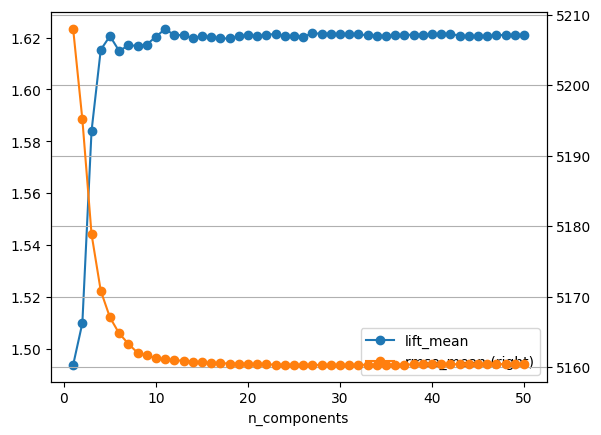

In [15]:
summary_df.plot(x='n_components', y=['lift_mean', 'rmse_mean'], secondary_y='rmse_mean', marker='o', grid=True)

In [16]:
summary_df.sort_values('lift_mean', ascending=False).head(10)

,n_components,rmse_mean,rmse_std,lift_mean,lift_std
10,11,5161.079040,15.007711,1.623341,0.015630
26,27,5160.296523,15.034138,1.621633,0.015585
27,28,5160.292917,15.034193,1.621517,0.015761
22,23,5160.334438,15.062927,1.621504,0.014821
28,29,5160.298607,15.033567,1.621473,0.015634
41,42,5160.385630,15.076118,1.621459,0.015507
40,41,5160.384635,15.069349,1.621424,0.015189
29,30,5160.299529,15.048358,1.621299,0.015385
31,32,5160.311201,15.034129,1.621251,0.015594
30,31,5160.303558,15.057185,1.621226,0.015321


Using knee rule, we see that RMSE stops rapid improvement at around 7 components, though lift stabilizes around 11 components, so we will use this number.

### PLS: model evaluation

In [17]:
from sklearn.model_selection import cross_validate
from src.metrics import lift_scorer
model = PLSRegressionModel(n_components=11)
cv_result = cross_validate(model, X_train, y_train, cv=5, scoring={'lift': lift_scorer, 'neg_mean_squared_error': 'neg_mean_squared_error', 'r2': 'r2'}, return_train_score=True)
cv_result = pd.DataFrame(cv_result)
cv_result['test_rmse'] = (-cv_result['test_neg_mean_squared_error']) ** 0.5
cv_result['train_rmse'] = (-cv_result['train_neg_mean_squared_error']) ** 0.5
cv_result

,fit_time,score_time,test_lift,train_lift,test_neg_mean_squared_error,train_neg_mean_squared_error,test_r2,train_r2,test_rmse,train_rmse
0,30.064657,2.628914,1.616400,1.627524,-2.676501e+07,-2.657920e+07,0.054503,0.055289,5173.490603,5155.501663
1,26.555385,2.337811,1.600265,1.633326,-2.661782e+07,-2.661466e+07,0.054404,0.055360,5159.246313,5158.939734
2,27.914078,2.049318,1.623576,1.624419,-2.656155e+07,-2.663453e+07,0.054443,0.055144,5153.789606,5160.865067
3,28.178841,2.069093,1.657385,1.619521,-2.657913e+07,-2.661637e+07,0.056132,0.055211,5155.495541,5159.105276
4,26.438305,1.933561,1.611523,1.627444,-2.665055e+07,-2.661121e+07,0.052892,0.055569,5162.417015,5158.605684


In [18]:
cv_result.agg(['mean', 'std'])

,fit_time,score_time,test_lift,train_lift,test_neg_mean_squared_error,train_neg_mean_squared_error,test_r2,train_r2,test_rmse,train_rmse
mean,27.830253,2.203740,1.62183,1.626447,-2.663481e+07,-2.661119e+07,0.054475,0.055315,5160.887815,5158.603485
std,1.473423,0.280054,0.02161,0.005039,8.055162e+04,2.004395e+04,0.001146,0.000164,7.799430,1.942995


Results are slightly worse than a single decision tree. 

### PLS: final evaluation

In [ ]:
from sklearn.metrics import root_mean_squared_error
model = PLSRegressionModel(n_components=11)
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train lift:", lift_score(y_train, y_pred_train))
print("Test lift:", lift_score(y_test, y_pred))
print("Train RMSE:", root_mean_squared_error(y_train, y_pred_train))
print("Test RMSE:", root_mean_squared_error(y_test, y_pred))
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

Train lift: 1.625440334504404
Test lift: 1.5867644032179848
Train RMSE: 5158.776118939078
Test RMSE: 5098.7811121069935
Train R2: 0.05525162228084224
Test R2: 0.05438306060539155


Threshold: 28.3644
Lift: 1.5868 times
Net improvement: $1.037692e+08 - $6.539672e+07 = $3.837247e+07


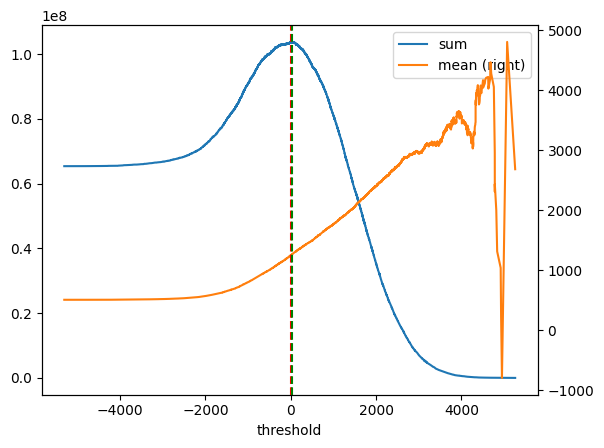

In [21]:
from src.metrics import build_curve, plot_curve
curve = build_curve(y_test, y_pred)
plot_curve(curve)

Curve is obviously smoother than with decision tree, lift is almost the same on test set, though it probably stems from random component. Interestingly, threshold is slightly positive.

Text(0, 0.5, 'predicted')

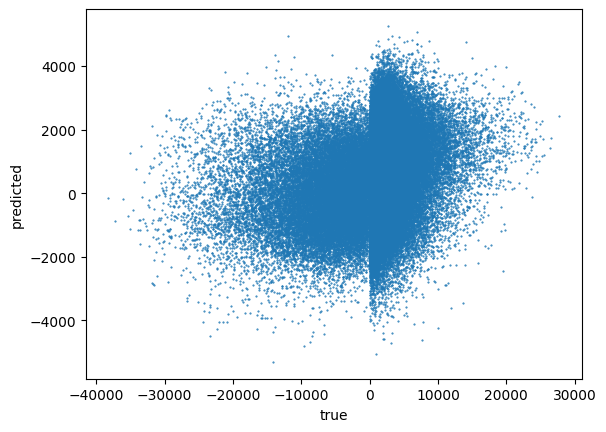

In [23]:
import matplotlib.pyplot as plt
plt.plot(y_test, y_pred, 'o', markersize=0.5)
plt.xlabel('true')
plt.ylabel('predicted')

Text(0, 0.5, 'residuals')

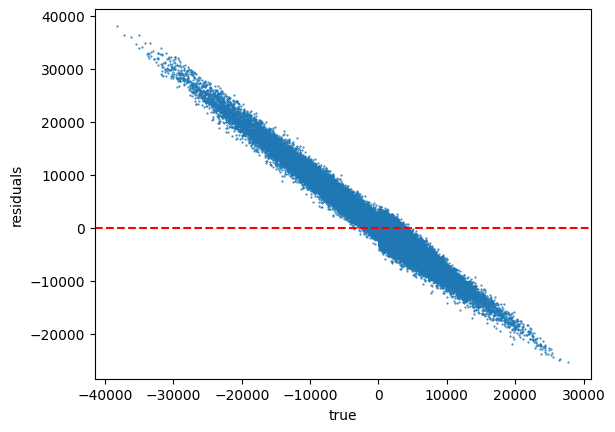

In [24]:
plt.plot(y_test, y_pred - y_test, 'o', markersize=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('true')
plt.ylabel('residuals')

Residuals seem to be more mean-driven compared to tree models, with worse separation between defaulted and paid off loans.

In [25]:
def calculate_vip(model):
    t = model.x_scores_
    w = model.x_rotations_
    q = model.y_loadings_
    
    p_features, h_components = w.shape
    vips = np.zeros((p_features,))
    
    s = np.diag(t.T @ t @ q.T @ q).reshape(h_components, -1)
    total_s = np.sum(s)
    
    for i in range(p_features):
        weight = np.array([ (w[i, j] / np.linalg.norm(w[:, j]))**2 for j in range(h_components) ])
        vips[i] = np.sqrt(p_features * (s.T @ weight).item() / total_s)
        
    return vips

In [26]:
vips = pd.Series(calculate_vip(model), index=model.preprocessor_.get_feature_names_out())

In [27]:
vips.sort_values(ascending=False).head(20)

year__issue_y                               3.154949
max__missingindicator_mths_since_rcnt_il    2.495457
skewed__all_util                            2.468613
skewed__il_util                             2.328552
skewed__open_rv_24m                         2.173212
skewed__open_rv_12m                         2.045614
skewed__open_il_24m                         2.037022
scaled__term                                2.025265
skewed__inq_last_12m                        1.960541
skewed__open_acc_6m                         1.948900
skewed__max_bal_bc                          1.873908
skewed__open_act_il                         1.861051
skewed__acc_open_past_24mths                1.857101
skewed__open_il_12m                         1.821333
skewed__total_bal_il                        1.740473
skewed__inq_fi                              1.631660
skewed__mort_acc                            1.521853
scaled__issue_m                             1.363056
mean__avg_cur_bal                           1.

Issue year vintage risk has a big importance. Months since recent installment opened being missing, utilization, number of opened trades, term follow. So it seems to utilize numeric categories better, but those also make sense. 

## Elastic Net
The problem with PLS is that it doesn't create nice interpretable models. In order to gain interpretability we should use models operating on features themselves, possibly giving up some of the predictive power. To reduce multicolinearity, we can remove correlated features one by one, but it doesn't remove whole groups of multicolinearity which can be not apparent from correlations. So we should use penalzied models hoping to have small regularization parameters so that coefficients are mostly interpretable. Ridge regression uses L2 penalty trying to reduce coefficients until they become more stable, but it introduces bias. Lasso uses L1 penalty and leaves only one feature from the group, so signal is lost and features end up arbitrarily selected. ElasticNet combines ridge and lasso penalties, so it can automatically retain or remove whole groups of correlated predictors, distribute coefficients relatively equally inside of the group, so coefficients end up rather correct. 

For tuning we will use ElasticNetCV with already preprocessed features, since it doesn't allow to add preprocessing pipeline.

In [7]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

In [18]:
from sklearn.linear_model import ElasticNetCV

elastic = ElasticNetCV(
    l1_ratio=[0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    alphas=np.logspace(-6, 2, 100),
    cv=5,
    max_iter=10000
)
elastic.fit(X_train_processed, y_train)
print(elastic.alpha_, elastic.l1_ratio_)

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4539544686.8515625, tolerance: 2616700122.864885
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3316093822215.043, tolerance: 2616700122.864885
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7697360995270.517, tolerance: 2616700122.864885
  model = cd_fast.enet_coordinate_descent_gram(
c:\Use

7.220809018385471e-05 0.2


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.541e+13, tolerance: 3.275e+09
  model = cd_fast.enet_coordinate_descent(


In [19]:
elastic.alpha_

np.float64(7.220809018385471e-05)

In [20]:
elastic.l1_ratio_

np.float64(0.2)

In [21]:
n_selected = (elastic.coef_ != 0).sum()
print(f"Selected features: {n_selected} / {len(elastic.coef_)}")

Selected features: 116 / 120


Dataset has many rows, so we don't need as much regularization. Basically enough to zero out the biggest correlations removing 4 features. Mostly ridge judging by l1 ratio.

In [8]:
from sklearn.linear_model import ElasticNet
ElasticNetRegressionModel = add_preprocessor(ElasticNet, preprocessor)

In [9]:
from sklearn.model_selection import cross_validate
from src.metrics import lift_scorer

model = ElasticNetRegressionModel(alpha=7e-05, l1_ratio=0.2, max_iter=1000)
cv_result = cross_validate(model, X_train, y_train, cv=5, scoring={'lift': lift_scorer, 'neg_mean_squared_error': 'neg_mean_squared_error', 'r2': 'r2'}, return_train_score=True)
cv_result = pd.DataFrame(cv_result)
cv_result['test_rmse'] = (-cv_result['test_neg_mean_squared_error']) ** 0.5
cv_result['train_rmse'] = (-cv_result['train_neg_mean_squared_error']) ** 0.5
cv_result

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.235e+13, tolerance: 2.617e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.234e+13, tolerance: 2.620e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

,fit_time,score_time,test_lift,train_lift,test_neg_mean_squared_error,train_neg_mean_squared_error,test_r2,train_r2,test_rmse,train_rmse
0,190.422276,1.816083,1.614366,1.626254,-2.675173e+07,-2.657064e+07,0.054972,0.055593,5172.207670,5154.672015
1,190.536209,1.790962,1.602482,1.630607,-2.660913e+07,-2.660392e+07,0.054713,0.055741,5158.403901,5157.899183
2,166.116403,1.518597,1.618971,1.624712,-2.655339e+07,-2.662269e+07,0.054734,0.055564,5152.997746,5159.718419
3,154.909977,1.794114,1.655388,1.618718,-2.656911e+07,-2.660744e+07,0.056487,0.055528,5154.523445,5158.240000
4,171.789281,1.513621,1.611034,1.626007,-2.664510e+07,-2.660020e+07,0.053086,0.055960,5161.889647,5157.538539


Coefficients are approximately correct, though not convergent

In [10]:
cv_result.agg(['mean', 'std'])

,fit_time,score_time,test_lift,train_lift,test_neg_mean_squared_error,train_neg_mean_squared_error,test_r2,train_r2,test_rmse,train_rmse
mean,174.754829,1.686675,1.620448,1.625259,-2.662569e+07,-2.660098e+07,0.054798,0.055677,5160.004482,5157.613631
std,15.586500,0.156016,0.020441,0.004279,7.900435e+04,1.899212e+04,0.001207,0.000177,7.651301,1.841382


Results are almost the same as in PLS, but we also gain interpretability.

### ElasticNet: final evaluation

In [12]:
from sklearn.metrics import root_mean_squared_error
from src.metrics import lift_score

In [13]:
model = ElasticNetRegressionModel(alpha=7e-05, l1_ratio=0.2, max_iter=1000)
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train lift:", lift_score(y_train, y_pred_train))
print("Test lift:", lift_score(y_test, y_pred))
print("Train RMSE:", root_mean_squared_error(y_train, y_pred_train))
print("Test RMSE:", root_mean_squared_error(y_test, y_pred))
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.543e+13, tolerance: 3.275e+09
  model = cd_fast.enet_coordinate_descent(


Train lift: 1.6252876166964676
Test lift: 1.5855680948996647
Train RMSE: 5157.801902813945
Test RMSE: 5098.337257557225
Train R2: 0.05560841318491683
Test R2: 0.05454768744591376


Basically PLS results

Threshold: 34.5914
Lift: 1.5856 times
Net improvement: $1.036910e+08 - $6.539672e+07 = $3.829423e+07


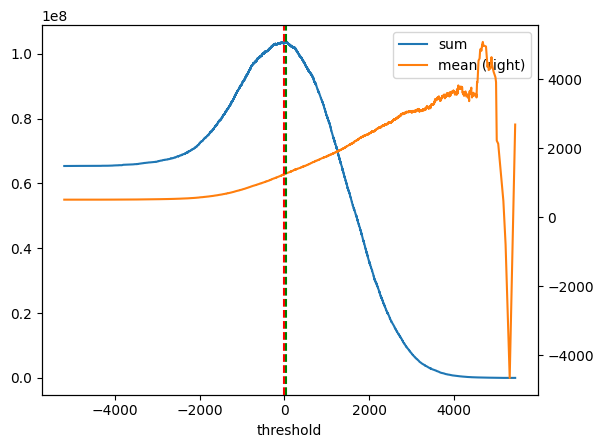

In [14]:
from src.metrics import build_curve, plot_curve
curve = build_curve(y_test, y_pred)
plot_curve(curve)

Text(0, 0.5, 'predicted')

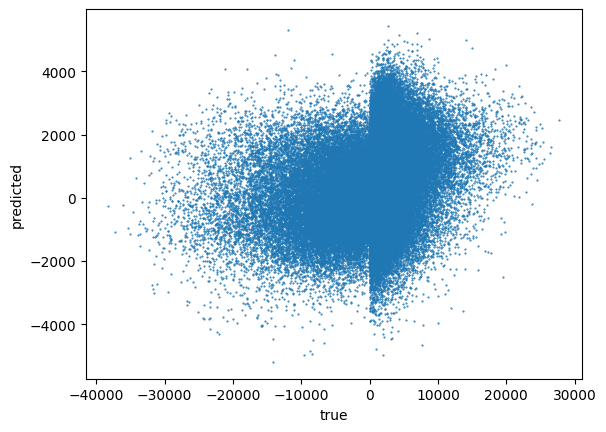

In [15]:
import matplotlib.pyplot as plt
plt.plot(y_test, y_pred, 'o', markersize=0.5)
plt.xlabel('true')
plt.ylabel('predicted')

Text(0, 0.5, 'residuals')

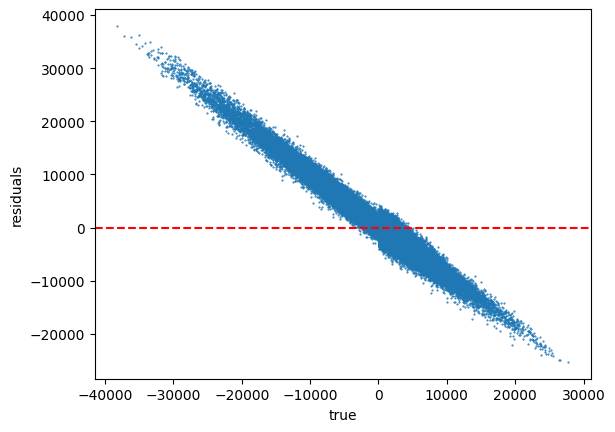

In [16]:
plt.plot(y_test, y_pred - y_test, 'o', markersize=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('true')
plt.ylabel('residuals')

In [21]:
pd.Series(model.coef_, index=model.preprocessor_.get_feature_names_out()).sort_values(key=abs, ascending=False).head(20)

remainder__is_verified                       -1809.313858
ohe__purpose_educational                     -1018.898392
ohe__purpose_small_business                   -840.326796
year__issue_y                                 -702.743293
ohe__home_ownership_OTHER                     -579.625160
ohe__home_ownership_NONE                       457.728807
skewed__num_actv_rev_tl                       -376.705587
ohe__purpose_major_purchase                   -353.101012
skewed__num_rev_tl_bal_gt_0                    338.847106
mean__total_bc_limit                           317.213015
remainder__is_individual                       313.207251
max__missingindicator_mo_sin_old_rev_tl_op    -308.028989
skewed__acc_open_past_24mths                  -304.796981
skewed__num_sats                               302.959032
skewed__all_util                              -299.474392
scaled__term                                  -276.126149
skewed__max_bal_bc                            -231.876539
mean__tot_hi_c

In [22]:
pd.Series(model.coef_, index=model.preprocessor_.get_feature_names_out()).sort_values(key=abs).head(20)

skewed__chargeoff_within_12_mths                 0.000000
skewed__num_tl_120dpd_2m                         0.000000
skewed__num_tl_30dpd                             0.000000
skewed__delinq_amnt                              0.000000
max__missingindicator_mths_since_rcnt_il        -1.135542
skewed__num_accts_ever_120_pd                    3.224227
skewed__open_il_24m                              4.569165
scaled__cr_line_m                               -4.874533
max__mo_sin_rcnt_tl                             -6.413385
max__missingindicator_mo_sin_rcnt_tl             6.614281
mean__total_il_high_credit_limit                -8.906144
skewed__tax_liens                               -9.323498
max__missingindicator_mths_since_recent_inq      9.629152
max__mths_since_recent_bc_dlq                   10.558788
max__mths_since_recent_revol_delinq            -11.104677
skewed__total_cu_tl                            -14.403984
max__missingindicator_mths_since_last_delinq    15.749543
max__missingin

As we saw during EDA, not surprisingly, binary column is_verified has a big coefficient. Other one-hot columns like education and small business purpose or home ownership in category OTHER or NONE also have big coefficients, since they are both minority columns and having different outcomes on average. Educational loans and business loans seem to lower return quite a bit. Active revolving trade have negative coefficient. Basically the biggest coefficients are connected with minority categories.